# Tutorial: Single Neuron Models in MOOSE: Passive compartment

<img src="./images/GFP_Neurons_Wiki_ManuelSchottdorf.png" alt="Neurons in a culture from a slice of rat cortex" width=600/>

Cultured neurons from a slice of rat cortex. *ManuelSchottdorf. CC BY-SA 4.0.*

*Original: https://commons.wikimedia.org/wiki/File:GFP_Neurons.png*

## Modelling a single neuron's cell body 

<img src="./images/neuron_cellbody_to_RC_circuit.png" alt="Cell membrane to RC circuit" width=800/>

*Image generated by ChatGPT*

## Modelling a single neuron's cell body
### $R_{ion} = R_{m} =$ membrane resistance
### $E_{m} =$ resting membrane potential/leak reversal potential

<img src="./images/passive_membrane_equivalent_circuit.png" alt="Cell membrane to RC circuit" width=300/>


It is easy to create such a compartment in MOOSE.

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

import moose


# Create a compartment called soma
soma = moose.Compartment('soma')

INFO:numexpr.utils:NumExpr defaulting to 12 threads.


### We can print the field names and their values of any moose object

In [2]:
moose.showfields(soma)


[/soma[0]]
name          = soma
className     = Compartment
tick          = 3
dt            = 5e-05
Cm            = 1.0
Em            = -0.06
Im            = 0.0
Ra            = 1.0
Rm            = 1.0
Vm            = -0.06
diameter      = 0.0
initVm        = -0.06
inject        = 0.0
length        = 0.0
x             = 0.0
x0            = 0.0
y             = 0.0
y0            = 0.0
z             = 0.0
z0            = 0.0



### Note that `length`, `diameter`, `x0`, `y0`, `z0`, and `x`, `y`, `z` are not used directly. The electrical properties (`Rm`, `Cm`, `Ra`, `Im`) are absolute quantities, not geometry dependent.

### Setting `Rm` and `Cm`
Notice that the default value of `Rm` and `Cm` is 1.0, which is unrealistically large for a cell (assuming SI units). We can set these to more biologically realistic values

In [3]:
soma.Rm = 1e4   # 10 kohm
soma.Cm = 100e-9 # 100 nF

## Setting up current injection

A common experiment to study the electrical properties of a neuron is to poke a sharp microelectrode into the cell body and inject electric current through it. The bath solution is connected to the ground terminal, so the outside of the cell is grounded.

<img src="./images/intracellular_current_injection.png" alt="Intracellular current injection" width=600/>

### You can use the `moose.PulseGen` class to generate a pulse current output.

In [4]:
inject = moose.PulseGen('inject')
inject.delay[0] = 10e-3   # start the current pulse after 10 ms 
inject.width[0] = 15e-3   # the pulse width will be 15 ms
inject.level[0] = 1e-6   # pulse current amplitude will be 1 uA

### Connect the output of the `PulseGen` to the current injection input of the `Compartment`

In [5]:
moose.connect(inject, 'output', soma, 'injectMsg')

<moose.SingleMsg path=/Msgs[0]/singleMsg[0] id=5 dataIndex=0 fieldIndex=0>

## Running the simulation

- `moose.reinit()` (re)initializes the model.
- `moose.start(time)` runs the simulation for spcified time.


In [6]:
moose.reinit()
moose.start(20e-3)

In [7]:
print(soma.Vm)

-0.05000043185749061


## Recording data over time
### But we got the Vm value at the end of the simulation. We need a way to record the values over time as the simulation progresses
`moose.Table` can sample a field value at regular intervals.

In [8]:
inject_tab = moose.Table('inject_tab')

# Connect the data-request output terminal of the table to the
# getter of the output field of the pulse generator
moose.connect(inject_tab, 'requestOut', inject, 'getOutputValue')

<moose.SingleMsg path=/Msgs[0]/singleMsg[1] id=5 dataIndex=1 fieldIndex=0>

In [9]:
vm_tab = moose.Table('Vm_tab')

# Connect the data-request output terminal of the table to the 
# getter of the Vm field of the compartment
moose.connect(vm_tab, 'requestOut', soma, 'getVm')

<moose.SingleMsg path=/Msgs[0]/singleMsg[2] id=5 dataIndex=2 fieldIndex=0>

In [10]:
moose.reinit()
moose.start(50e-3)

### The data is accumulated as `Table.vector`. We can plot this against time

Text(0.5, 0, 'Time (s)')

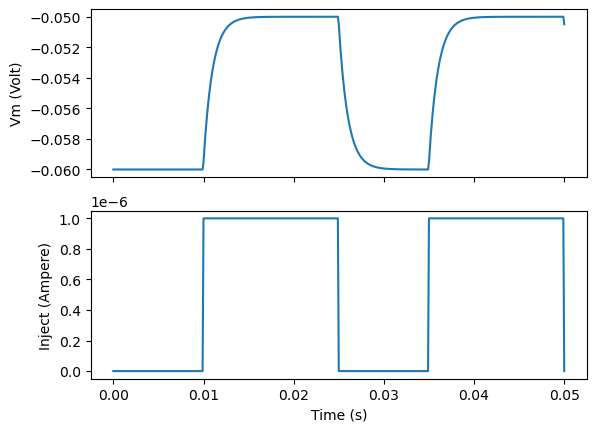

In [11]:
t = np.arange(len(vm_tab.vector)) * vm_tab.dt
fig, axes = plt.subplots(nrows=2, sharex='all')
axes[0].plot(t, vm_tab.vector)
axes[0].set_ylabel('Vm (Volt)')
axes[1].plot(t, inject_tab.vector)
axes[1].set_ylabel('Inject (Ampere)')
axes[1].set_xlabel('Time (s)')

## Exercise
Now change `Rm` and `Cm` values keeping everything else constant. What do you observe?

Text(0.5, 0, 'Time (s)')

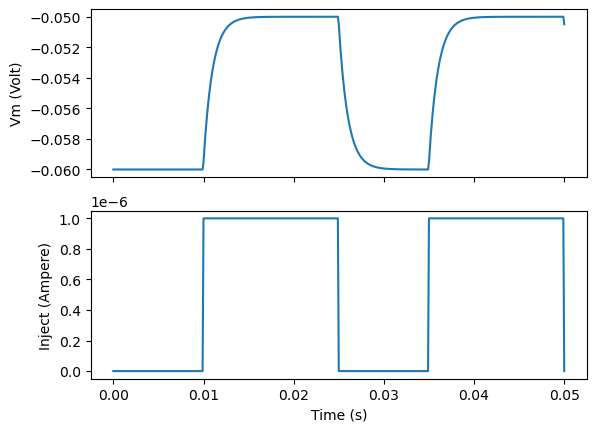

In [12]:
# Uncomment the two lines below and insert values
# soma.Rm = <insert value>
# soma.Vm = <insert value>
moose.reinit()
moose.start(50e-3)

t = np.arange(len(vm_tab.vector)) * vm_tab.dt
fig, axes = plt.subplots(nrows=2, sharex='all')
axes[0].plot(t, vm_tab.vector)
axes[0].set_ylabel('Vm (Volt)')
axes[1].plot(t, inject_tab.vector)
axes[1].set_ylabel('Inject (Ampere)')
axes[1].set_xlabel('Time (s)')